
<!-- # Chương 1: Đánh giá Toàn diện Thuật toán FP-Growth
Dataset: `chess.dat`

Notebook này được chia thành 3 phần kiểm thử độc lập:
1. **Correctness (Tính đúng đắn):** `eval_correctness()` và `vis_correctness()`
2. **Performance (Hiệu năng):** `eval_performance()` và `vis_performance()`
3. **Scalability (Khả năng mở rộng):** `eval_scalability()` và `vis_scalability()` -->

# Evaluate

## Dependencies

In [1]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
using .Utils
logger = Logger()

success(logger, "Dependencies loaded")


[success] Dependencies loaded


In [2]:
Random.seed!(42)
CONFIG = Dict(
    "dataset_path" => "../data/benchmark/chess.dat/chess.dat",
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    
    
    "proposed_result" => "../results/chess_julia.txt",
    "baseline_result" => "../results/chess_spmf.txt",

    "min_sups" => [0.9, 0.8, 0.7, 0.6],
    "performance_result" => "../results/chess_metrics_minsup.csv",
    
    "data_ratios" => [0.4, 0.6, 0.8, 1.0], 
    "Minimum Support" => 0.7,
    "scalability_result" => "../results/chess_metrics_scalability.csv"
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")


[success] Config loaded


## Helpers

In [3]:
include("../src/eval.jl")
using .Utils
success(logger, "Helper loaded")


[success] Helper loaded


## Correctness Evaluation


__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Verify accuracy at the threshold MinSup=70.0%
[process] Executing Julia From Scratch (Proposed)...
[process] Executing SPMF Built-in (Baseline)...
[info] Comparing results...

__________________________________________________
[phase]  Visualize
__________________________________________________
[success] Correct (48731 frequent itemsets)


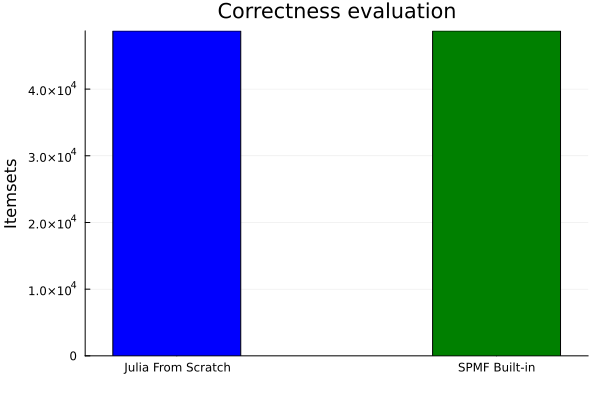

In [4]:
correctness_results = eval_correctness(CONFIG, logger)
vis_correctness(correctness_results, logger)


## Performance Evaluation

[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 3196
[process] Executing with min_sup = 90.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.004s | Memory: 2.3 MB  (median of 5 runs)
   [metric] SPMF Built-in (Baseline)  → Time: 0.084s | Memory: 12.74 MB
[process] Executing with min_sup = 80.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.009s | Memory: 5.9 MB  (median of 5 runs)
   [metric] SPMF Built-in (Baseline)  → Time: 0.116s | Memory: 20.36 MB


Benchmarking...  50%|██████████████████                 |  ETA: 0:00:05

[process] Executing with min_sup = 70.0% in 5 times...


Benchmarking...  75%|███████████████████████████        |  ETA: 0:00:02

   [metric] Julia From Scratch (Proposed)  → Time: 0.035s | Memory: 28.03 MB  (median of 5 runs)
   [metric] SPMF Built-in (Baseline)  → Time: 0.207s | Memory: 21.02 MB
[process] Executing with min_sup = 60.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:10


   [metric] Julia From Scratch (Proposed)  → Time: 0.172s | Memory: 121.04 MB  (median of 5 runs)
   [metric] SPMF Built-in (Baseline)  → Time: 0.441s | Memory: 84.26 MB
[success] Saved at ../results/chess_metrics_minsup.csv

__________________________________________________
[phase]  visualize
__________________________________________________


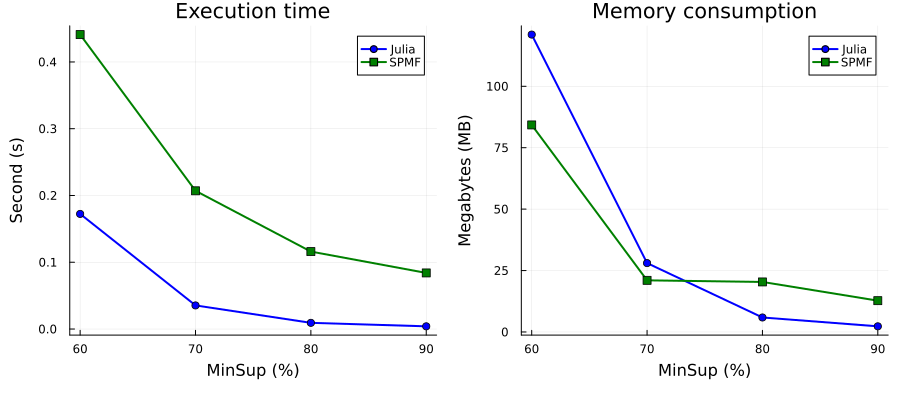

In [5]:
performance_result = eval_performance(CONFIG, logger)
vis_performance(performance_result, logger)


## Scalability Evaluation 

[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=70.0%
[process] Data Ratio = 40.0% (1279 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 1.33s | SPMF Built-in (Baseline) Time: 0.67s
[process] Data Ratio = 60.0% (1918 giao dịch) ...


Benchmarking...  50%|██████████████████                 |  ETA: 0:00:04

   [metric] Julia From Scratch (Proposed) Time: 0.29s | SPMF Built-in (Baseline) Time: 0.393s
[process] Data Ratio = 80.0% (2557 giao dịch) ...


Benchmarking...  75%|███████████████████████████        |  ETA: 0:00:02

   [metric] Julia From Scratch (Proposed) Time: 0.051s | SPMF Built-in (Baseline) Time: 0.24s
[process] Data Ratio = 100.0% (3196 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:06


   [metric] Julia From Scratch (Proposed) Time: 0.038s | SPMF Built-in (Baseline) Time: 0.217s
[success] Saved at ../results/chess_metrics_scalability.csv

__________________________________________________
[phase]  visualize
__________________________________________________


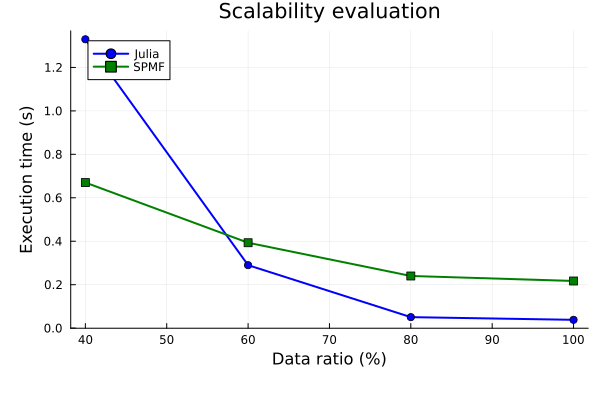

In [6]:
scalability_result = eval_scalability(CONFIG, logger)
vis_scalability(scalability_result, logger)
